### Imports and CUDA

In [114]:
# Torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import json
import os
import io
import random
import numpy as np
from helper_functions import *
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pickle
from tqdm.auto import tqdm
from torch.utils.data import Subset

# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [115]:
# Detect available device: CUDA > DirectML (AMD GPU) > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
else:
    try:
        import torch_directml
        device = torch_directml.device()
        print(f"Using DirectML: {device}")
    except:
        device = torch.device("cpu")
        print(f"Using CPU")

Using CPU


### DvXray Dataset
A large-scale dual-view X-ray baggage dataset for prohibited item detection.

- **Views:** Overlook (OL) & Side (SD) X-ray images
- **15 threat classes:** Gun, Knife, Hammer, Battery, etc.
- **Negative samples:** Benign baggage
- **Annotations:** JSON with bounding boxes

In [116]:
# DvXray Dataset
class DvXrayDataset(Dataset):
    """DvXray Dataset: dual-view X-ray baggage dataset for prohibited item detection.
    
    Args:
        transform: Optional transform to apply to each image.
        download: If True, downloads the dataset from Google Drive if not found.
    """
    
    def __init__(self, transform=None, download=False):
        # Download if requested
        if download and not check_dvxray_exists():
            download_and_extract_dvxray()
        neg_dir, pos_dir = get_directories()
        
        # Read dataset from directories
        self.samples = []
        self.labels = {}  # cache: ol_path -> list of label strings
        self.transform = transform

        # Add negative images into dataset
        for fname in os.listdir(neg_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(neg_dir, base + '_OL.png')
                sd = os.path.join(neg_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 0))    # negatives = 0
                    self.labels[ol] = ["Benign"]
                else:
                    print(f"Missing SD for negative: {base}")

        # Add positive images into dataset
        for fname in os.listdir(pos_dir):
            if fname.endswith('_OL.png'):
                base = fname.replace('_OL.png', '')
                ol = os.path.join(pos_dir, base + '_OL.png')
                sd = os.path.join(pos_dir, base + '_SD.png')
                if os.path.exists(sd):
                    self.samples.append((ol, sd, 1))    # positives = 1
                    json_path = os.path.join(pos_dir, base + '.json')
                    obj_labels = []
                    if os.path.exists(json_path):
                        with open(json_path) as f:
                            data = json.load(f)
                        objects = data.get("objects")
                        if isinstance(objects, list) and len(objects) > 0:
                            for obj in objects:
                                obj_labels.append(obj["label"])
                        else:
                            obj_labels = ["Benign"]
                    else:
                        obj_labels = ["Benign"]
                    self.labels[ol] = obj_labels
                else:
                    print(f"Missing SD for positive: {base}")

        # Build label_map: Benign=0, threat classes sorted from 1
        all_labels = set()
        for label_list in self.labels.values():
            all_labels.update(label_list)

        self.label_map = {"Benign": 0}
        self.label_map.update(
            {label: i + 1 for i, label in enumerate(sorted(all_labels - {"Benign"}))}
        )
        self.num_classes = len(self.label_map)
    
    def __getitem__(self, idx):
        """Returns (image, vector, binary)"""
        ol_path, sd_path, binary_label = self.samples[idx]
        ol = Image.open(ol_path).convert('RGB')
        sd = Image.open(sd_path).convert('RGB')
        if self.transform:
            ol = self.transform(ol)
            sd = self.transform(sd)

        image = torch.cat([ol, sd], dim=0)
        multi_hot = torch.zeros(self.num_classes)
        for label_str in self.labels[ol_path]:
            if label_str in self.label_map:
                multi_hot[self.label_map[label_str]] = 1.0
    
        # (6 channel 224 x 224 image, vector of length num_classes, label)
        return image, multi_hot, binary_label  
    
    def __len__(self):
        """Return sample count"""
        return len(self.samples)
    
    def __repr__(self):
        """Return string representation of dataset"""
        pos_count = sum(1 for _, _, binary_label in self.samples if binary_label == 1)
        neg_count = len(self.samples) - pos_count
        return (f"DvXrayDataset(samples={len(self.samples)}, pos={pos_count}, neg={neg_count}, "
                f"classes={self.num_classes})\n"
                f"Labels: {', '.join(f'{v}:{k}' for k, v in self.label_map.items())}")

### Load the DvXray Dataset

In [117]:
# EfficientNet expects 224x224 images (ImageNet standard)
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 224 is the resolution of B0 model
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406]
    , std=[0.229, 0.224, 0.225]), # values are of the ILSVRC-2012 dataset that EfficientNet-B0 was pretrained on.
])

# Load the data (downloads if not present)
dataset = DvXrayDataset(transform=transform, download=True)
print(dataset)

DvXrayDataset(samples=16000, pos=5000, neg=11000, classes=16)
Labels: 0:Benign, 1:Bat, 2:Battery, 3:Dart, 4:Fireworks, 5:Gun, 6:Hammer, 7:Knife, 8:Lighter, 9:Pliers, 10:Pressure_vessel, 11:Razor_blade, 12:Saw_blade, 13:Scissors, 14:Screwdriver, 15:Wrench


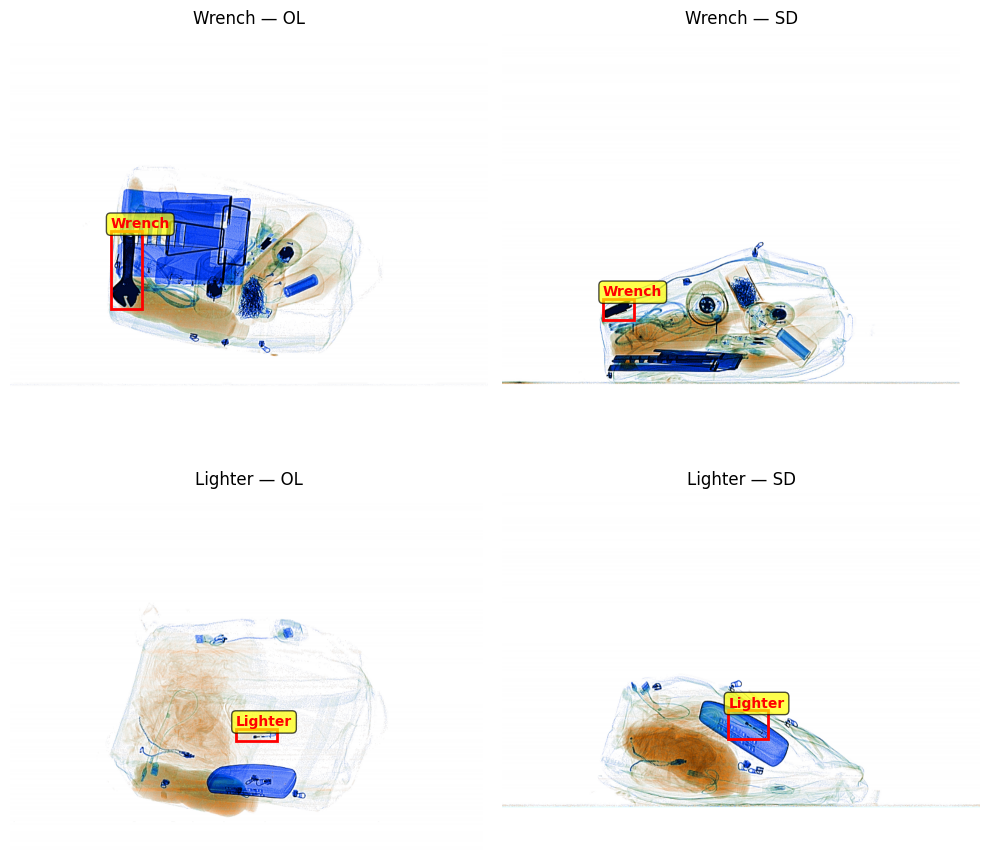

In [118]:
# Show first 2 classes
visualize_samples(dataset, n_classes=2)

### Split dataset (8-1-1) into Train-Validate-Test

In [119]:
# Split the subset
scale = 1.0  # NOTE; set this to 1.0 during actual training 
total_size = int(len(dataset) * scale)
indices = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(SEED))[:total_size].tolist()
subset = Subset(dataset, indices)

validate_size = int(0.10 * total_size)
test_size = int(0.10 * total_size)
train_size = total_size - validate_size - test_size

train_set, validate_set, test_set = random_split(
    subset, [train_size, validate_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

batch_size = 32
train_loader = DataLoader(train_set, batch_size, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(validate_set, batch_size)
test_loader = DataLoader(test_set, batch_size)

print(f"Train set size: {len(train_set)}")
print(f"Validate set size: {len(validate_set)}")
print(f"Test set size: {len(test_set)}\n")
print(f"Number of classes: {dataset.num_classes}")
print(f"Sample shape: {train_set[0][0].shape}")

Train set size: 12800
Validate set size: 1600
Test set size: 1600

Number of classes: 16
Sample shape: torch.Size([6, 224, 224])


### Adapt EfficientNet Model for Transfer Learning
We use a pretrained EfficientNet-B0 from torchvision and adapt it for:
- 6-channel input (dual-view X-ray: OL + SD) by averaging the first conv layer weights
- Two output heads: multi-label classification and binary threat detection

In [120]:
class MyEfficientNet(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        """Adapt EfficientNet_B0 to the dataset."""
        super().__init__()
        
        # Load pretrained EfficientNet-B0
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        self.efficientnet = models.efficientnet_b0(weights=weights)
        
        # Modify first conv layer to accept 6-channel input (OL:3 + SD:3) instead of 3 
        old_conv = self.efficientnet.features[0][0]
        new_conv = nn.Conv2d(6, 32, kernel_size=3, stride=2, padding=1, bias=False) # kernel size, stride, padding follow those of EfficientNet
        with torch.no_grad():
            mean_weight = old_conv.weight.mean(dim=1, keepdim=True)         # average the 3-channel weights
            new_conv.weight = nn.Parameter(mean_weight.repeat(1, 6, 1, 1))  # use averaged weight for 6-channel weights 
        self.efficientnet.features[0][0] = new_conv
        
        # Modify last classifier layer to have two output heads: 1280 → 512 → {num_classes, 2}
        in_features = self.efficientnet.classifier[1].in_features  # 1280
        self.efficientnet.classifier = nn.Identity()   # to retain 1280 feature vector (EfficientNet: 1280 -> 1000 classes)
        self.shared_hidden = nn.Linear(in_features, 512)
        self.dropout = nn.Dropout(0.3)                 # tuneable
        self.multi_label_head = nn.Linear(512, num_classes)    # multi-label classifier (16 classes)
        self.binary_head = nn.Linear(512, 2)             # binary classifier 
    
    def forward(self, x):
        """Forward pass. (batch, 6, 224, 224) → multi_logits, binary_logits"""
        x = self.efficientnet(x)
        x = self.shared_hidden(x)
        x = F.relu(x)
        x = self.dropout(x)
        multi_out = self.multi_label_head(x)    # object classification
        binary_out = self.binary_head(x)  # threat/no threat
        
        return multi_out, binary_out

    def freeze_layers(self, *targets):
        """Freeze selected layers of the model.
        
        Args:
            targets: One or more of:
                - 'features' (str): freeze all feature extractor layers (features[0] through features[-1])
                - 'heads' (str): freeze the custom FC heads (shared_hidden, multi_label_head, binary_head)
                - 'initial_conv' (str): freeze only the first conv layer (6-channel adapter)
                - int: freeze a specific features block by index (e.g. 0 = initial conv+bn, 1 = first MBConv block)
                - range/list of ints: freeze multiple features blocks (e.g. range(3) or [0,1,2])
        
        Examples:
            model.freeze_layers('features')           # freeze entire backbone
            model.freeze_layers('heads')              # freeze only custom heads
            model.freeze_layers('initial_conv')       # freeze just the 6-channel adapter
            model.freeze_layers(range(3))             # freeze features[0], [1], [2]
            model.freeze_layers(1, 2, 3)              # freeze features[1], [2], [3]
        """
        # Collect parameter groups to freeze
        params_to_freeze = []
        
        for target in targets:
            if target == 'features':
                params_to_freeze.extend(self.efficientnet.features.parameters())
            elif target == 'heads':
                params_to_freeze.extend(self.shared_hidden.parameters())
                params_to_freeze.extend(self.multi_label_head.parameters())
                params_to_freeze.extend(self.binary_head.parameters())
            elif target == 'initial_conv':
                params_to_freeze.extend(self.efficientnet.features[0].parameters())
            elif isinstance(target, int):
                params_to_freeze.extend(self.efficientnet.features[target].parameters())
            elif isinstance(target, (range, list)):
                for idx in target:
                    params_to_freeze.extend(self.efficientnet.features[idx].parameters())
            else:
                raise ValueError(f"Unknown freeze target: {target}")
        
        for param in params_to_freeze:
            param.requires_grad = False

    def unfreeze_all(self):
        """Unfreeze all layers (make everything trainable)."""
        for param in self.parameters():
            param.requires_grad = True

    def print_trainable_summary(self):
        """Print a summary of which layers are frozen vs trainable."""
        print("\n=== Trainable Layers Summary ===")
        
        # Features
        for i, block in enumerate(self.efficientnet.features):
            trainable = sum(1 for p in block.parameters() if p.requires_grad)
            total = sum(1 for p in block.parameters())
            status = "TRAINABLE" if trainable > 0 else "FROZEN"
            block_name = f"Initial Conv+BN" if i == 0 else f"MBConv Block {i}"
            print(f"  features[{i}] ({block_name:20s}): {status} ({trainable}/{total} params)")
        
        # Heads
        head_descriptions = {
            'shared_hidden': 'Shared Hidden Layer',
            'multi_label_head': 'Multi-Label Head',
            'binary_head': 'Binary Head',
        }
        for name, module in [('shared_hidden', self.shared_hidden), ('multi_label_head', self.multi_label_head), ('binary_head', self.binary_head)]:
            trainable = sum(1 for p in module.parameters() if p.requires_grad)
            total = sum(1 for p in module.parameters())
            status = "TRAINABLE" if trainable > 0 else "FROZEN"
            print(f"  {name:16s} ({head_descriptions[name]:20s}): {status} ({trainable}/{total} params)")
        
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"\n  Total: {trainable_params:,} / {total_params:,} parameters trainable ({100*trainable_params/total_params:.1f}%)\n")

In [121]:
# Initialize EfficientNet model
model = MyEfficientNet(num_classes=dataset.num_classes, pretrained=True).to(device)
print(model)

MyEfficientNet(
  (efficientnet): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              

### Selecting Loss Functions
The model has two output heads, so we use two loss functions:
- **`BCEWithLogitsLoss`** — multi-label classification over the 16-dimensional one-hot vector (15 threat classes + Benign).
- **`CrossEntropyLoss`** — binary threat detection (threat vs. benign).

In [122]:
# Define loss function
orig_dataset = train_set.dataset.dataset  # Navigate through Subset chain
orig_indices = [train_set.dataset.indices[i] for i in train_set.indices]
labels = [orig_dataset.samples[i][2] for i in orig_indices]
neg = labels.count(0)
pos = labels.count(1)
print(f"Class balance: {neg} negatives, {pos} positives")
weights = torch.tensor([1.0, neg / pos]).to(device)

criterion_multi = nn.BCEWithLogitsLoss()                # handles multi-hot targets
criterion_binary = nn.CrossEntropyLoss(weight=weights)  # handles binary 

Class balance: 8783 negatives, 4017 positives


### Defining Train Function

We will be training the model with differents amount of unfreezed layers as part of tuning later on so we first define a train function to keep the code clean.

Apart from the usual training logic, there is also:
- Saving of model weights
- Saving of model training history (pickle)

In [123]:
def train_model(model, experiment_name: str, optimizer: torch.optim.Optimizer, override=False):
    """Train model and save weights + history.
    
    This function uses the following objects so ensure they appear in the same scope as the function: 
    - train_loader, 
    - val_loader, 
    - criterion_multi, 
    - criterion_binary, 
    """
    # Check if results already exists
    save_path = Path(get_result_directory()) / experiment_name
    save_path.mkdir(parents=True, exist_ok=True)
    
    results_file = save_path / "results.pkl"
    model_file = save_path / "best_model.pth"
    
    if not override and results_file.exists() and model_file.exists():
        print(f"⚠️ Training already done for {experiment_name}")
        return load_training_results(experiment_name)
    
    # Train
    best_val_acc = 0    # to identify overfitting 
    train_losses, val_losses, val_accs = [], [], []     # for caching
    num_epochs = 20
    for epoch in tqdm(range(num_epochs), desc="Epochs"):
        
        model.train()

        # Process train batches
        total_loss = 0
        for images, multi_labels, binary_labels in tqdm(train_loader, desc="Train", leave=False):
            # Predict labels
            images = images.to(device)
            multi_out, binary_out = model(images)

            # Calculate loss
            multi_labels = multi_labels.to(device)
            binary_labels = binary_labels.to(device)
            loss_multi = criterion_multi(multi_out, multi_labels)
            loss_binary = criterion_binary(binary_out, binary_labels)
            loss = loss_multi + loss_binary
            total_loss += loss.item()

            # Backpropagate
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Cache losses 
        train_loss = total_loss / len(train_loader)
        train_losses.append(train_loss)

        # Evaluate model (to find overfitting and save best weights)
        val_loss = 0
        correct = 0
        total = 0    
        with torch.no_grad():
            
            model.eval()

            # Process validate batches
            for images, multi_labels, binary_labels in tqdm(val_loader, desc="Val", leave=False):
                # Predict labels
                images = images.to(device)
                multi_out, binary_out = model(images)
                
                # Calculate loss
                multi_labels = multi_labels.to(device)
                binary_labels = binary_labels.to(device)
                loss_multi = criterion_multi(multi_out, multi_labels)
                loss_binary = criterion_binary(binary_out, binary_labels)
                loss = loss_multi + loss_binary
                val_loss += loss.item()

                # Count accurate binary predictions
                preds = torch.argmax(binary_out, dim=1)
                correct += (preds == binary_labels).sum().item()
                total += binary_labels.size(0)

        # Cache losses and accuracy
        val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Print epoch training result
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        # Save weights with of best models 
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path / 'best_model.pth')
            print(f"  → Best model saved (val_acc: {val_acc:.4f})")

    # Done with training, save results with pickle
    results = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'best_epoch': val_accs.index(max(val_accs)) + 1,
        'experiment_name': experiment_name,
        'num_epochs': num_epochs
    }
    
    # Pickle training results
    with open(results_file, 'wb') as f:
        pickle.dump(results, f)
    
    # Model weights already saved during training (when val_acc improved)
    print(f"✅ Training complete: {experiment_name}")
    print(f"   Best val_acc: {best_val_acc:.4f}")
    
    return results


def load_training_results(experiment_name):
    """Load previously saved training results."""
    save_path = Path(get_result_directory()) / experiment_name
    
    results_file = save_path / "results.pkl"
    
    if results_file.exists():
        with open(results_file, 'rb') as f:
            return pickle.load(f)
    else:
        print(f"⚠️ No results found for {experiment_name}")
        return None

### Freezing Layers and Training
We experiment with progressive unfreezing from the back to tune for best performance.

- **Phase 1:** Freeze all backbone MBConv blocks. Train only initial conv and the classifier heads.
- **Phase 2:** Freeze MBConv blocks less the last 2 (`features[7]`–`[8]`). Train initial conv + heads + 2 deep layers.
- **Phase 3:** Freeze MBConv blocks less the last 4 (`features[5]`–`[8]`). Train initial conv + heads + 4 deep layers.

**Phase 1:** Freeze all backbone MBConv blocks (`features[1]`–`[8]`). Train only initial conv and the classifier heads.

In [124]:
# Phase 1:
model.freeze_layers(1, 2, 3, 4, 5, 6, 7, 8)
model.print_trainable_summary()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
_ = train_model(model,
                experiment_name="efficientNetB0_train_phase1",
                optimizer=optimizer,
                override=False)



=== Trainable Layers Summary ===
  features[0] (Initial Conv+BN     ): TRAINABLE (3/3 params)
  features[1] (MBConv Block 1      ): FROZEN (0/10 params)
  features[2] (MBConv Block 2      ): FROZEN (0/26 params)
  features[3] (MBConv Block 3      ): FROZEN (0/26 params)
  features[4] (MBConv Block 4      ): FROZEN (0/39 params)
  features[5] (MBConv Block 5      ): FROZEN (0/39 params)
  features[6] (MBConv Block 6      ): FROZEN (0/52 params)
  features[7] (MBConv Block 7      ): FROZEN (0/13 params)
  features[8] (MBConv Block 8      ): FROZEN (0/3 params)
  shared_hidden    (Shared Hidden Layer ): TRAINABLE (2/2 params)
  multi_label_head (Multi-Label Head    ): TRAINABLE (2/2 params)
  binary_head      (Binary Head         ): TRAINABLE (2/2 params)

  Total: 666,898 / 4,673,518 parameters trainable (14.3%)

⚠️ Training already done for efficientNetB0_train_phase1


**Phase 2:** Freeze MBConv blocks less the last one (`features[8]`). Train initial conv + heads + 1 deep layers.

In [125]:
# Phase 2
model = MyEfficientNet(num_classes=dataset.num_classes, pretrained=True).to(device)     # fresh model
model.freeze_layers(1, 2, 3, 4, 5, 6, 7)
model.print_trainable_summary()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
_ = train_model(model,
                experiment_name="efficientNetB0_train_phase2",
                optimizer=optimizer,
                override=False)


=== Trainable Layers Summary ===
  features[0] (Initial Conv+BN     ): TRAINABLE (3/3 params)
  features[1] (MBConv Block 1      ): FROZEN (0/10 params)
  features[2] (MBConv Block 2      ): FROZEN (0/26 params)
  features[3] (MBConv Block 3      ): FROZEN (0/26 params)
  features[4] (MBConv Block 4      ): FROZEN (0/39 params)
  features[5] (MBConv Block 5      ): FROZEN (0/39 params)
  features[6] (MBConv Block 6      ): FROZEN (0/52 params)
  features[7] (MBConv Block 7      ): FROZEN (0/13 params)
  features[8] (MBConv Block 8      ): TRAINABLE (3/3 params)
  shared_hidden    (Shared Hidden Layer ): TRAINABLE (2/2 params)
  multi_label_head (Multi-Label Head    ): TRAINABLE (2/2 params)
  binary_head      (Binary Head         ): TRAINABLE (2/2 params)

  Total: 1,079,058 / 4,673,518 parameters trainable (23.1%)

⚠️ Training already done for efficientNetB0_train_phase2


**Phase 3:** UPhase 3:** Freeze MBConv blocks less the last 2 (`features[7]`–`[8]`). Train initial conv + heads + 2 deep layers.

In [126]:
# Phase 3
model = MyEfficientNet(num_classes=dataset.num_classes, pretrained=True).to(device)     # fresh model
model.freeze_layers(1, 2, 3, 4, 5, 6)
model.print_trainable_summary()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
_ = train_model(model,
                experiment_name="efficientNetB0_train_phase3",
                optimizer=optimizer,
                override=False)


=== Trainable Layers Summary ===
  features[0] (Initial Conv+BN     ): TRAINABLE (3/3 params)
  features[1] (MBConv Block 1      ): FROZEN (0/10 params)
  features[2] (MBConv Block 2      ): FROZEN (0/26 params)
  features[3] (MBConv Block 3      ): FROZEN (0/26 params)
  features[4] (MBConv Block 4      ): FROZEN (0/39 params)
  features[5] (MBConv Block 5      ): FROZEN (0/39 params)
  features[6] (MBConv Block 6      ): FROZEN (0/52 params)
  features[7] (MBConv Block 7      ): TRAINABLE (13/13 params)
  features[8] (MBConv Block 8      ): TRAINABLE (3/3 params)
  shared_hidden    (Shared Hidden Layer ): TRAINABLE (2/2 params)
  multi_label_head (Multi-Label Head    ): TRAINABLE (2/2 params)
  binary_head      (Binary Head         ): TRAINABLE (2/2 params)

  Total: 1,796,290 / 4,673,518 parameters trainable (38.4%)

⚠️ Training already done for efficientNetB0_train_phase3


### Evaluation

In [ ]:
def test_model(model_class, experiment_name, dataset, device):
    """Test a saved model on test set."""
    global test_loader  # Use the same test_loader from your notebook
    
    save_path = Path(get_result_directory()) / experiment_name
    model_file = save_path / "best_model.pth"
    results_file = save_path / "results.pkl"
    
    if not model_file.exists():
        print(f"⚠️ No model found for {experiment_name}")
        return None
    
    # Load training results to get best_val_acc
    training_results = load_training_results(experiment_name)
    
    # Create and load model
    model = model_class(num_classes=dataset.num_classes, pretrained=True).to(device)
    
    # Load without device-specific logic
    with open(model_file, 'rb') as f:
        buffer = io.BytesIO(f.read())
        state_dict = torch.load(buffer, map_location=device, weights_only=False)

    model.load_state_dict(state_dict)
    #model.load_state_dict(torch.load(model_file, weights_only=False))

    model.eval()
    
    # Test
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, _, binary_labels in test_loader:
            images = images.to(device)
            binary_labels = binary_labels.to(device)
            
            _, binary_out = model(images)
            preds = torch.argmax(binary_out, dim=1)
            
            correct += (preds == binary_labels).sum().item()
            total += binary_labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(binary_labels.cpu().numpy())
    
    test_acc = correct / total
    
    # Save test results
    test_results = {
        'test_acc': test_acc,
        'best_val_acc': training_results['best_val_acc'] if training_results else None,
        'experiment_name': experiment_name,
        'total_samples': total,
        'correct': correct
    }
    
    test_file = save_path / "test_results.pkl"
    with open(test_file, 'wb') as f:
        pickle.dump(test_results, f)
    
    print(f"\n{'='*50}")
    print(f"📊 Test Results for {experiment_name}")
    print(f"   Best Val Acc: {test_results['best_val_acc']:.4f}")
    print(f"   Test Acc: {test_acc:.4f} ({correct}/{total})")
    print(f"{'='*50}\n")
    
    # Optional: print classification report
    from sklearn.metrics import classification_report
    print(classification_report(all_labels, all_preds, target_names=['No Threat', 'Threat']))
    
    return test_results

In [128]:

# Later (or in a separate notebook), test all saved models
test1 = test_model(MyEfficientNet, "efficientNetB0_train_phase1", dataset, device)
test2 = test_model(MyEfficientNet, "efficientNetB0_train_phase2", dataset, device)
test3 = test_model(MyEfficientNet, "efficientNetB0_train_phase3", dataset, device)

# Compare
print("\n📊 Final Comparison:")
print(f"Phase 1: Val={test1['best_val_acc']:.4f}, Test={test1['test_acc']:.4f}")
print(f"Phase 2: Val={test2['best_val_acc']:.4f}, Test={test2['test_acc']:.4f}")
print(f"Phase 2: Val={test3['best_val_acc']:.4f}, Test={test3['test_acc']:.4f}")


📊 Test Results for efficientNetB0_train_phase1
   Best Val Acc: 0.9756
   Test Acc: 0.9712 (1554/1600)

              precision    recall  f1-score   support

   No Threat       0.96      1.00      0.98      1101
      Threat       0.99      0.92      0.95       499

    accuracy                           0.97      1600
   macro avg       0.98      0.96      0.97      1600
weighted avg       0.97      0.97      0.97      1600


📊 Test Results for efficientNetB0_train_phase2
   Best Val Acc: 0.9788
   Test Acc: 0.9919 (1587/1600)

              precision    recall  f1-score   support

   No Threat       0.99      1.00      0.99      1101
      Threat       1.00      0.98      0.99       499

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600


📊 Test Results for efficientNetB0_train_phase3
   Best Val Acc: 0.9856
   Test Acc: 0.9956 (1593/1600)

              precision    reca

### Training Visualization

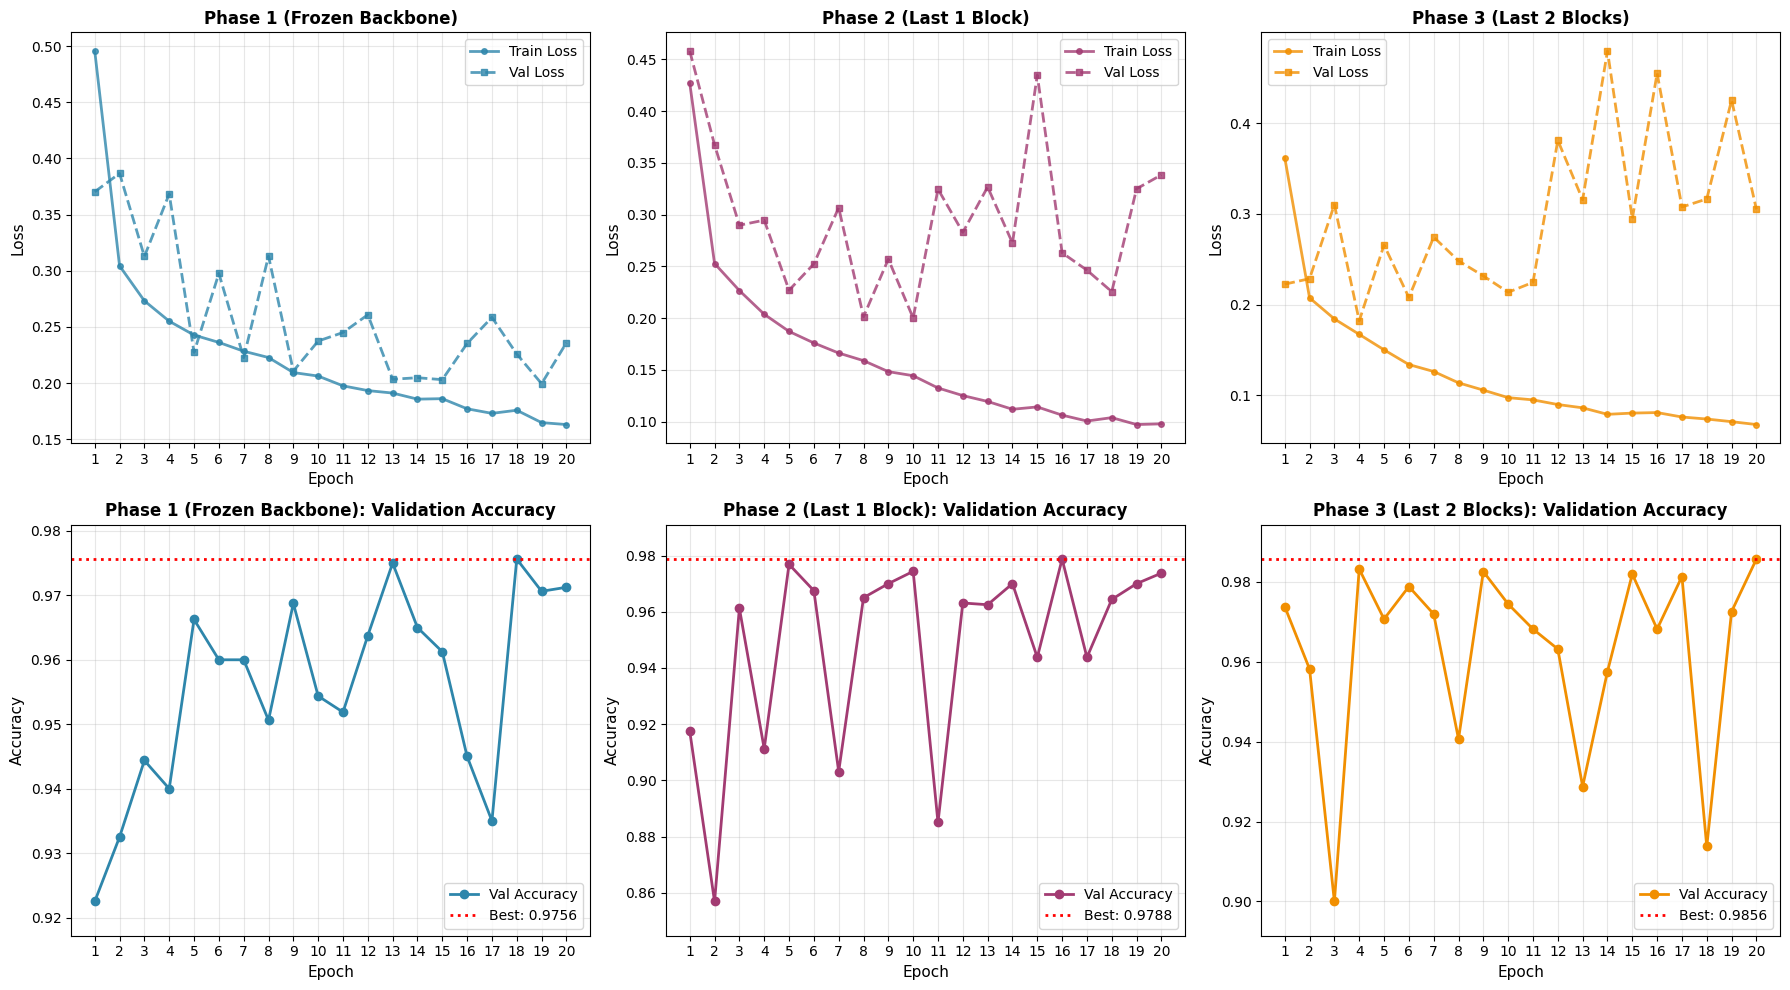

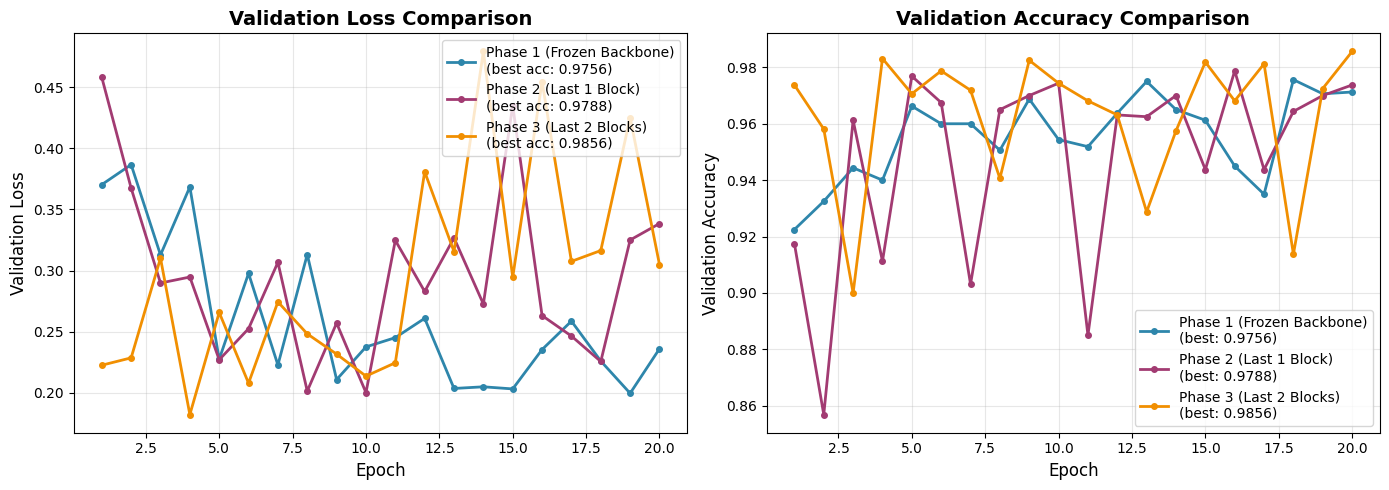


📊 TRAINING SUMMARY

Phase 1 (Frozen Backbone):
  Val Accs: ['0.9225', '0.9325', '0.9444', '0.9400', '0.9663', '0.9600', '0.9600', '0.9506', '0.9688', '0.9544', '0.9519', '0.9637', '0.9750', '0.9650', '0.9613', '0.9450', '0.9350', '0.9756', '0.9706', '0.9712']
  Best Val Accuracy: 0.9756 (Epoch 18)
  Final Train Loss:  0.1631
  Final Val Loss:    0.2360

Phase 2 (Last 1 Block):
  Val Accs: ['0.9175', '0.8569', '0.9613', '0.9113', '0.9769', '0.9675', '0.9031', '0.9650', '0.9700', '0.9744', '0.8850', '0.9631', '0.9625', '0.9700', '0.9437', '0.9788', '0.9437', '0.9644', '0.9700', '0.9738']
  Best Val Accuracy: 0.9788 (Epoch 16)
  Final Train Loss:  0.0978
  Final Val Loss:    0.3385

Phase 3 (Last 2 Blocks):
  Val Accs: ['0.9738', '0.9581', '0.9000', '0.9831', '0.9706', '0.9788', '0.9719', '0.9406', '0.9825', '0.9744', '0.9681', '0.9631', '0.9287', '0.9575', '0.9819', '0.9681', '0.9812', '0.9137', '0.9725', '0.9856']
  Best Val Accuracy: 0.9856 (Epoch 20)
  Final Train Loss:  0.0679
  Fin

In [133]:
# Plot training curves for all three phases
import matplotlib.pyplot as plt
import numpy as np

# Load all three results
results1 = load_training_results("efficientNetB0_train_phase1")
results2 = load_training_results("efficientNetB0_train_phase2")
results3 = load_training_results("efficientNetB0_train_phase3")

results_list = [results1, results2, results3]
phase_names = ['Phase 1 (Frozen Backbone)', 'Phase 2 (Last 1 Block)', 'Phase 3 (Last 2 Blocks)']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Create figure with proper subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (results, name, color) in enumerate(zip(results_list, phase_names, colors)):
    num_epochs = results['num_epochs']
    train_losses = results['train_losses']
    val_losses = results['val_losses']
    val_accs = results['val_accs']
    best_val_acc = results['best_val_acc']
    
    epochs = range(1, num_epochs + 1)
    
    # Top row: Loss plots
    ax_loss = axes[0, i]
    ax_loss.plot(epochs, train_losses, 'o-', color=color, label='Train Loss', 
                 markersize=4, linewidth=2, alpha=0.8)
    ax_loss.plot(epochs, val_losses, 's--', color=color, label='Val Loss', 
                 markersize=4, linewidth=2, alpha=0.8)
    ax_loss.set_xlabel('Epoch', fontsize=11)
    ax_loss.set_ylabel('Loss', fontsize=11)
    ax_loss.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax_loss.legend(fontsize=10)
    ax_loss.grid(True, alpha=0.3)
    ax_loss.set_xticks(epochs)
    
    # Bottom row: Accuracy plots - REMOVED y-limit restriction
    ax_acc = axes[1, i]
    ax_acc.plot(epochs, val_accs, 'o-', color=color, label='Val Accuracy', 
                markersize=6, linewidth=2)
    ax_acc.axhline(y=best_val_acc, color='red', linestyle=':', 
                   linewidth=2, label=f'Best: {best_val_acc:.4f}')
    ax_acc.set_xlabel('Epoch', fontsize=11)
    ax_acc.set_ylabel('Accuracy', fontsize=11)
    ax_acc.set_title(f'{name}: Validation Accuracy', fontsize=12, fontweight='bold')
    ax_acc.legend(fontsize=10)
    ax_acc.grid(True, alpha=0.3)
    ax_acc.set_xticks(epochs)
    # Auto-determine y-limits with some padding
    min_acc = min(val_accs)
    max_acc = max(val_accs)
    padding = (max_acc - min_acc) * 0.1
    ax_acc.set_ylim([max(0, min_acc - padding), min(1, max_acc + padding)])

plt.tight_layout()
plt.savefig('efficientnet_training_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Create comparison figure - also with auto y-limits
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
for results, name, color in zip(results_list, phase_names, colors):
    epochs = range(1, results['num_epochs'] + 1)
    axes2[0].plot(epochs, results['val_losses'], 'o-', color=color, 
                  label=f"{name}\n(best acc: {results['best_val_acc']:.4f})", 
                  markersize=4, linewidth=2)
axes2[0].set_xlabel('Epoch', fontsize=12)
axes2[0].set_ylabel('Validation Loss', fontsize=12)
axes2[0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes2[0].legend(fontsize=10, loc='upper right')
axes2[0].grid(True, alpha=0.3)

# Accuracy comparison
for results, name, color in zip(results_list, phase_names, colors):
    epochs = range(1, results['num_epochs'] + 1)
    axes2[1].plot(epochs, results['val_accs'], 'o-', color=color, 
                  label=f"{name}\n(best: {results['best_val_acc']:.4f})", 
                  markersize=4, linewidth=2)
axes2[1].set_xlabel('Epoch', fontsize=12)
axes2[1].set_ylabel('Validation Accuracy', fontsize=12)
axes2[1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes2[1].legend(fontsize=10, loc='lower right')
axes2[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('efficientnet_phase_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary with all accuracy values for verification
print("\n" + "="*60)
print("📊 TRAINING SUMMARY")
print("="*60)
for i, (results, name) in enumerate(zip(results_list, phase_names)):
    print(f"\n{name}:")
    print(f"  Val Accs: {[f'{acc:.4f}' for acc in results['val_accs']]}")
    print(f"  Best Val Accuracy: {results['best_val_acc']:.4f} (Epoch {results['best_epoch']})")
    print(f"  Final Train Loss:  {results['train_losses'][-1]:.4f}")
    print(f"  Final Val Loss:    {results['val_losses'][-1]:.4f}")

# Determine best phase
best_idx = max(range(3), key=lambda i: results_list[i]['best_val_acc'])
print(f"\n🏆 Best performing phase: {phase_names[best_idx]}")
print(f"   Validation Accuracy: {results_list[best_idx]['best_val_acc']:.4f}")
print("="*60)